# 04 - Evaluation Metrics and Diagnostic Visualizations

## Definition
Evaluation quantifies model behavior beyond single accuracy number.

## Theory
Multi-class classification needs per-class and aggregate views.

## Motivation
Packaging decisions (version promotion, rollback, monitoring thresholds) need trustworthy metrics.


In [1]:
from pathlib import Path
import os

CWD = Path.cwd()
ROOT = CWD if (CWD / "pyproject.toml").exists() else CWD.parent
os.chdir(ROOT)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/benchmarks").mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)


In [3]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "roc_auc_ovr": roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"),
}
metrics


{'accuracy': 0.9,
 'precision_macro': 0.9023569023569024,
 'recall_macro': 0.9,
 'f1_macro': 0.899749373433584,
 'roc_auc_ovr': 0.9883333333333333}

## Metric Explanation
- **Accuracy**: overall correctness
- **Precision**: predicted class purity
- **Recall**: how much true class captured
- **F1**: precision-recall balance
- **ROC AUC (OvR)**: ranking quality per class


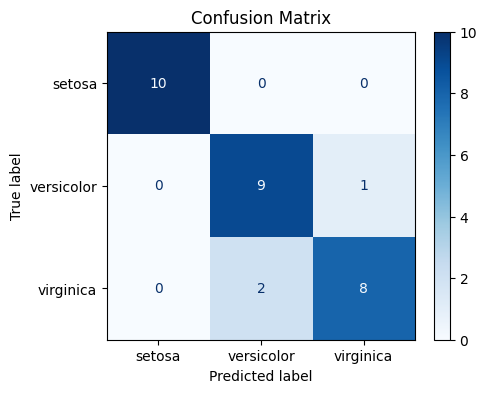

Saved: outputs/figures/notebook04_confusion_matrix.png


In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names, cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
cm_path = Path("outputs/figures/notebook04_confusion_matrix.png")
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


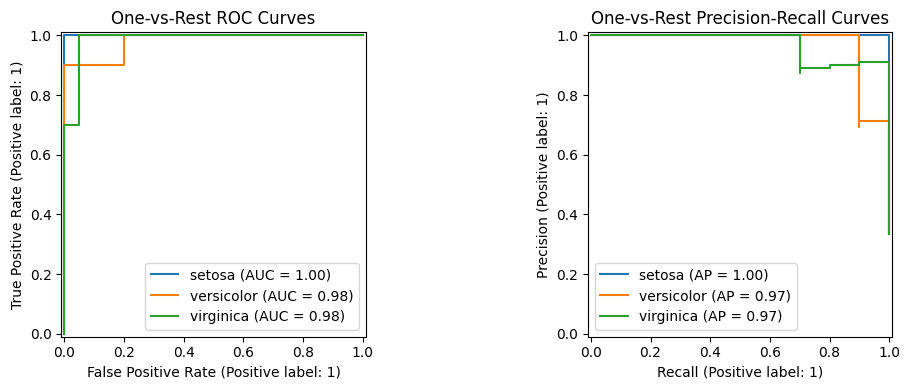

Saved: outputs/figures/notebook04_roc_pr_curves.png


In [5]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for idx, name in enumerate(iris.target_names):
    RocCurveDisplay.from_predictions(y_test_bin[:, idx], y_prob[:, idx], name=name, ax=axes[0])
axes[0].set_title("One-vs-Rest ROC Curves")

for idx, name in enumerate(iris.target_names):
    PrecisionRecallDisplay.from_predictions(y_test_bin[:, idx], y_prob[:, idx], name=name, ax=axes[1])
axes[1].set_title("One-vs-Rest Precision-Recall Curves")

fig.tight_layout()
curve_path = Path("outputs/figures/notebook04_roc_pr_curves.png")
fig.savefig(curve_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {curve_path}")
